<a href="https://colab.research.google.com/github/pavithra130608/Pavi/blob/main/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

df=pd.read_csv('temp.csv')
df.head(30)

,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony,Property Size,Property Name,PARK_FACIL,City,Floor,Unnamed: 14,Unnamed: 15
0,Casagrand ECR 14,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",1.990000e+08,"Kanathur Reddikuppam, Chennai",2583.0,7700.0,Best 4 BHK Apartment for modern-day lifestyle ...,4.0,Yes,4 BHK,"Flat for sale in Kanathur Reddikuppam, Chennai",Yes,Chennai,0,NaN,NaN
1,"Ramanathan Nagar, Pozhichalur,Chennai",10 BHK Independent House for sale in Pozhichal...,2.250000e+08,"Ramanathan Nagar, Pozhichalur,Chennai",7000.0,3210.0,Looking for a 10 BHK Independent House for sal...,6.0,Yes,10 BHK,"Independent House for sale in Pozhichalur, Che...",No,Chennai,0,NaN,NaN
2,DAC Prapthi,"3 BHK Flat for sale in West Tambaram, Chennai",1.000000e+07,"Kasthuribai Nagar, West Tambaram,Chennai",1320.0,7580.0,"Property for sale in Tambaram, Chennai. This 3...",3.0,No,3 BHK,"Flat for sale in West Tambaram, Chennai",Yes,Chennai,0,NaN,NaN
3,"Naveenilaya,Chepauk, Triplicane,Chennai",7 BHK Independent House for sale in Triplicane...,3.330000e+08,"Naveenilaya,Chepauk, Triplicane,Chennai",4250.0,7840.0,Entire Building for sale with 7 units of singl...,5.0,Yes,7 BHK,"Independent House for sale in Triplicane, Chennai",No,Chennai,0,NaN,NaN
4,VGN Spring Field Phase 1,"2 BHK Flat for sale in Avadi, Chennai",4.800000e+08,"Avadi, Chennai",960.0,5000.0,"Property for sale in Avadi, Chennai. This 2 BH...",3.0,Yes,2 BHK,"Flat for sale in Avadi, Chennai",Yes,Chennai,0,NaN,NaN
5,KG Earth Homes,"2 BHK Flat for sale in Siruseri, Chennai",4.000000e+08,"Siruseri, Chennai",940.0,4250.0,"Price negotiable. Big hall, big balcony, gated...",3.0,No,2 BHK,"Flat for sale in Siruseri, Chennai",No,Chennai,0,NaN,NaN
6,"THIRAN FLATS ,Gowrivakkam, Sembakkam,Chennai","2 BHK Flat for sale in Sembakkam, Chennai",6.000000e+08,"THIRAN FLATS ,Gowrivakkam, Sembakkam,Chennai",880.0,6820.0,2 BHK Apartment for sale in Chennai. This prop...,3.0,Yes,2 BHK,"Flat for sale in Sembakkam, Chennai",No,Chennai,0,NaN,NaN
7,TK Jasmine Grove,3 BHK Independent House for sale in Mahindra W...,7.235000e+09,"Mahindra World City, Chennai",1700.0,4250.0,A 3 BHK Independent House for sale in Mahindra...,3.0,Yes,3 BHK,Independent House for sale in Mahindra World C...,No,Chennai,0,NaN,NaN
8,Avenue,"2 BHK Flat for sale in West Tambaram, Chennai",4.200000e+08,"Brindavan Colony, West Tambaram,Chennai",840.0,5000.0,Check out this 2 BHK Apartment for sale in Tam...,3.0,No,2 BHK,"Flat for sale in West Tambaram, Chennai",No,Chennai,0,NaN,NaN
9,Guru Kothai Aparts,"1 BHK Flat for sale in Chromepet, Chennai",3.000000e+08,"New Colony, Chromepet,Chennai",535.0,5610.0,We are the proud owners of this 1 bhk apartmen...,2.0,No,1 BHK,"Flat for sale in Chromepet, Chennai",No,Chennai,0,NaN,NaN


In [5]:
#------------------ Data Cleaning ------------------ #
df['Balcony'] = df['Balcony'].astype(str).str.strip().str.title().replace({'Yes': 1, 'No': 0})
df['Balcony'] = pd.to_numeric(df['Balcony'], errors='coerce').fillna(0).astype(int)

df['PARK_FACIL'] = df['PARK_FACIL'].astype(str).str.strip().str.title().replace({'Yes': 1, 'No': 0})
df['PARK_FACIL'] = pd.to_numeric(df['PARK_FACIL'], errors='coerce').fillna(0).astype(int)


In [6]:
# ------------------ Encode City Names ------------------ #
valid_cities = ['Chennai', 'Bangalore', 'Hyderabad', 'Mumbai']

# Ensure 'City' column has only valid cities
df['City'] = df['City'].astype(str).str.strip().str.title()
df = df[df['City'].isin(valid_cities)]  # Keep only valid cities

# Encode valid city names
df['City'] = df['City'].replace({
    'Chennai': 1, 'Bangalore': 2, 'Hyderabad': 3, 'Mumbai': 4
})


<ipython-input-6-f454e3dd293d>:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['City'] = df['City'].replace({
<ipython-input-6-f454e3dd293d>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['City'] = df['City'].replace({


In [8]:
 #Extract Property Size
df['Property Size'] = df['Property Size'].astype(str).str.extract(r'(\d+)')
df = df.dropna(subset=['Property Size'])
df['Property Size'] = df['Property Size'].astype(int)

# Convert other columns
df['Floor'] = pd.to_numeric(df['Floor'], errors='coerce').fillna(0)
df['Total_Area'] = pd.to_numeric(df['Total_Area'], errors='coerce').fillna(0)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').fillna(0)

# Add new feature: Price per sqft
df['Price_per_SQFT'] = df['Price'] / df['Total_Area']
df['Price_per_SQFT'] = df['Price_per_SQFT'].replace([np.inf, -np.inf], np.nan).fillna(0)


<ipython-input-8-28ec198ea896>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Property Size'] = df['Property Size'].astype(int)
<ipython-input-8-28ec198ea896>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Floor'] = pd.to_numeric(df['Floor'], errors='coerce').fillna(0)
<ipython-input-8-28ec198ea896>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

In [9]:
# ------------------ Summary Statistics ------------------ #
print("\n--- Summary Statistics ---")
print(df[['Property Size', 'Total_Area', 'Price']].describe())


--- Summary Statistics ---
       Property Size    Total_Area         Price
count    6874.000000   6874.000000  6.874000e+03
mean        2.813355   1542.785860  5.068966e+08
std         1.652018   1245.016022  8.438641e+08
min         1.000000    167.000000  1.000000e+07
25%         2.000000    900.000000  1.210000e+08
50%         2.000000   1200.000000  4.000000e+08
75%         3.000000   1700.000000  6.500000e+08
max        10.000000  15000.000000  9.999000e+09



--- Correlation Matrix ---
               Property Size  Total_Area  PARK_FACIL   Balcony     Floor  \
Property Size       1.000000    0.633685    0.008383  0.272903 -0.092583   
Total_Area          0.633685    1.000000    0.023837  0.325406 -0.068079   
PARK_FACIL          0.008383    0.023837    1.000000  0.013956 -0.005857   
Balcony             0.272903    0.325406    0.013956  1.000000 -0.020953   
Floor              -0.092583   -0.068079   -0.005857 -0.020953  1.000000   
City               -0.046191   -0.021990   -0.010043 -0.008664  0.172046   
Price              -0.133706   -0.132639   -0.012940 -0.079985  0.000467   

                   City     Price  
Property Size -0.046191 -0.133706  
Total_Area    -0.021990 -0.132639  
PARK_FACIL    -0.010043 -0.012940  
Balcony       -0.008664 -0.079985  
Floor          0.172046  0.000467  
City           1.000000 -0.043162  
Price         -0.043162  1.000000  


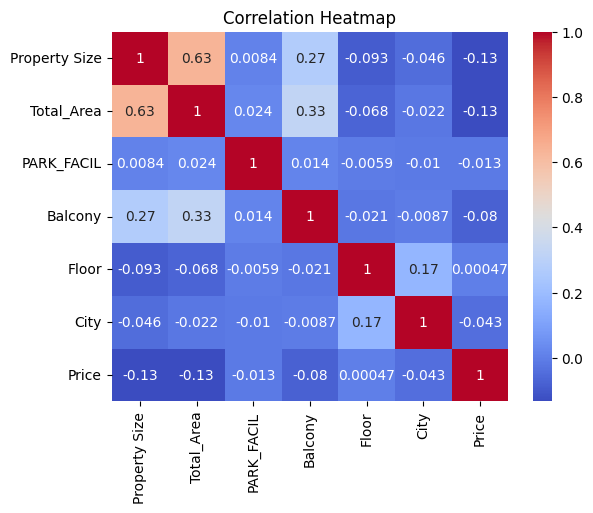

In [10]:
# ------------------ Correlation Matrix ------------------ #
print("\n--- Correlation Matrix ---")
corr = df[['Property Size', 'Total_Area', 'PARK_FACIL', 'Balcony', 'Floor', 'City', 'Price']].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

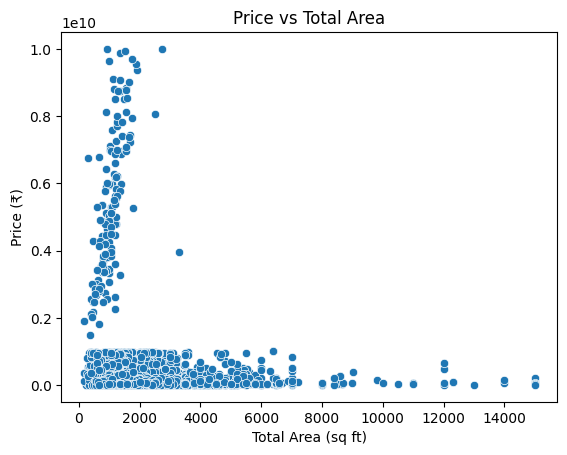

In [11]:
# ------------------ Price vs Features ------------------ #
sns.scatterplot(x='Total_Area', y='Price', data=df)
plt.title("Price vs Total Area")
plt.xlabel("Total Area (sq ft)")
plt.ylabel("Price (₹)")
plt.show()

In [13]:
# ------------------ Model Training ------------------ #
X = df[['Property Size', 'Total_Area', 'PARK_FACIL', 'Balcony', 'Floor', 'City']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Save model
joblib.dump(lr_model, 'house_price_model.pkl')

['house_price_model.pkl']

In [14]:

# ------------------ Model Evaluation ------------------ #
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\n--- Model Evaluation ---")
print(f"R² Score: {r2:.4f} ({r2*100:.2f}%)")
print(f"RMSE: ₹{rmse:,.2f}")



--- Model Evaluation ---
R² Score: 0.0164 (1.64%)
RMSE: ₹846,502,454.47


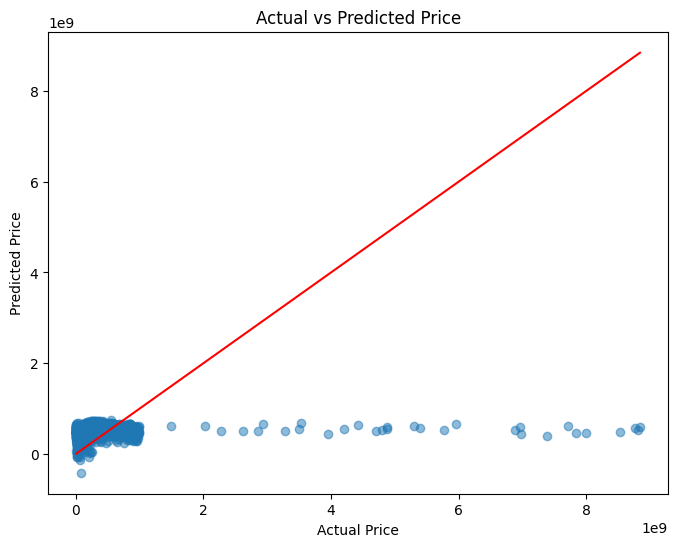

In [15]:
# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()


In [19]:
# Coefficients
print("\n--- Model Coefficients ---")
print(pd.DataFrame(lr_model.coef_, X.columns, columns=['Coefficient']))
# ------------------ Print Low & High Budget Properties in Each City ------------------ #

# City mapping
city_name_map = {1: 'Chennai', 2: 'Bangalore', 3: 'Hyderabad', 4: 'Mumbai'}

# Loop through encoded city IDs
for city_code, city_name in city_name_map.items():
    city_data = df[df['City'] == city_code]

    if city_data.empty:
        print(f"\n--- {city_name} ---\nNo data available.")
        continue

    print(f"\n--- {city_name} ---")

    # Low Budget Property
    low_budget_city = city_data.loc[city_data['Price'].idxmin()]
    print(f"Low Budget Property: {low_budget_city['Name']} - Price: ₹{low_budget_city['Price']:,}")

    # High Budget Property
    high_budget_city = city_data.loc[city_data['Price'].idxmax()]
    print(f"High Budget Property: {high_budget_city['Name']} - Price: ₹{high_budget_city['Price']:,}")



--- Model Coefficients ---
                Coefficient
Property Size -4.514430e+07
Total_Area    -4.651921e+04
PARK_FACIL    -7.098539e+06
Balcony       -4.050804e+07
Floor         -8.810453e+05
City          -7.085222e+07

--- Chennai ---
Low Budget Property: DAC Prapthi - Price: ₹10,000,000.0
High Budget Property:  Golden Jubilee Apartment - Price: ₹9,999,000,000.0

--- Bangalore ---
Low Budget Property: Nallurhalli, Whitefield,Bangalore - Price: ₹10,000,000.0
High Budget Property: Lake City, Bommanahalli,Bangalore - Price: ₹9,545,000,000.0

--- Hyderabad ---
Low Budget Property: Aditya Sri satya apartments,Raghavendra Colony, Kondapur,Hyderabad - Price: ₹10,000,000.0
High Budget Property: Hallmark Sunnyside - Price: ₹9,932,000,000.0

--- Mumbai ---
Low Budget Property: Vraj Villa - Price: ₹10,000,000.0
High Budget Property: Navkar City Phase II Part 3 - Price: ₹4,899,000,000.0


In [20]:
# ------------------ User Input Prediction ------------------ #
TEST_MODE = False

if TEST_MODE:
    property_size = 3
    area = 1200.0
    balcony = 1
    parking = 1
    floor = 2
    city = 1
else:
    try:
        print("\n--- Predict Property Price ---")
        property_size = int(input("Enter number of BHKs: "))
        area = float(input("Enter total area (sq ft): "))
        balcony = int(input("Balcony? (1=Yes, 0=No): "))
        parking = int(input("Parking? (1=Yes, 0=No): "))
        floor = int(input("Floor number: "))
        city = int(input("Enter City (Chennai=1, Bangalore=2, Hyderabad=3, Mumbai=4): "))
    except Exception as e:
        print("Invalid input:", e)
        exit()

input_data = [[property_size, area, parking, balcony, floor, city]]
predicted_price = lr_model.predict(input_data)[0]
predicted_price = max(predicted_price, 0)
print(f"\nPredicted Price: ₹{predicted_price:,.2f}")

# ------------------ Matching Entry ------------------ #
matching_row = df.loc[
    (df['Property Size'] == property_size) &
    (df['Total_Area'].round(2) == round(area, 2)) &
    (df['PARK_FACIL'] == parking) &
    (df['Balcony'] == balcony) &
    (df['Floor'] == floor) &
    (df['City'] == city)
]

if not matching_row.empty:
    print("\nMatching Property Details:\n", matching_row)
else:
    print("\nNo exact match found in the dataset.")


--- Predict Property Price ---
Enter number of BHKs: 3
Enter total area (sq ft): 1317
Balcony? (1=Yes, 0=No): 0
Parking? (1=Yes, 0=No): 0
Floor number: 0
Enter City (Chennai=1, Bangalore=2, Hyderabad=3, Mumbai=4): 1

Predicted Price: ₹606,276,058.39

Matching Property Details:
           Name                                 Property Title        Price  \
15   SSM Nagar  3 BHK Flat for sale in Perungalathur, Chennai  570000000.0   
150  SSM Nagar  3 BHK Flat for sale in Perungalathur, Chennai  520000000.0   

                   Location  Total_Area  Price_per_SQFT  \
15   Perungalathur, Chennai      1317.0   432801.822323   
150  Perungalathur, Chennai      1317.0   394836.750190   

                                           Description  Baths  Balcony  \
15   Situated at Alapakkam, New Perungalathur. SURR...    3.0        0   
150  Check out this 3 BHK Apartment for sale in New...    3.0        0   

     Property Size                            Property Name  PARK_FACIL  City  \
15 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


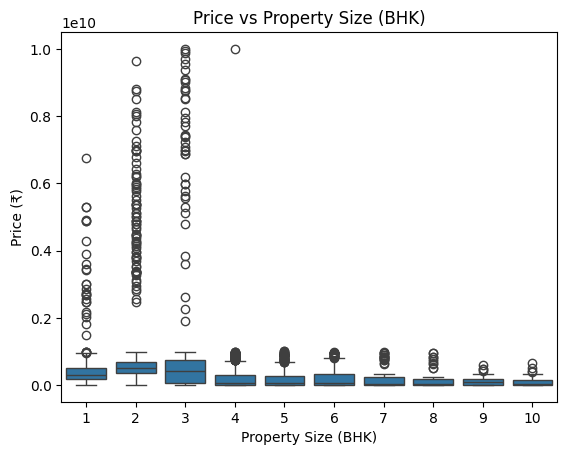

In [21]:
sns.boxplot(x='Property Size', y='Price', data=df)
plt.title("Price vs Property Size (BHK)")
plt.xlabel("Property Size (BHK)")
plt.ylabel("Price (₹)")
plt.show()